In [17]:
# ==================== TASK 1: Problem Identification ====================

import os

print("=== TASK 1: Problem Identification ===\n")

# Dataset path
dataset_path = '/content/dataset/images'

# List classes
classes = sorted([folder for folder in os.listdir(dataset_path)
                  if os.path.isdir(os.path.join(dataset_path, folder)) and folder != '.DS_Store'])

print("Classes found in the dataset:")
for cls in classes:
    print(" -", cls)

print("\nTotal number of classes:", len(classes))

# Count images per class
print("\nNumber of images per class:")
for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    num_images = len([f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f" - {cls}: {num_images} images")

=== TASK 1: Problem Identification ===

Classes found in the dataset:
 - dent
 - normal
 - scratch
 - stain

Total number of classes: 4

Number of images per class:
 - dent: 120 images
 - normal: 120 images
 - scratch: 120 images
 - stain: 120 images


**Selected Problem Type: Image Classification**

### Explanation:
The dataset contains images organized into 4 different folders (*dent*, *normal*,*scratch*, *stain*). Each folder represents one class, and each class has 120 images.

This structure is ideal for an **Image Classification** problem, where the CNN model needs to classify an entire image into one of these four defect categories.

It is not object detection or segmentation because we only have class-level labels (folder names), not bounding boxes or masks.

=== TASK 2: Dataset Exploration ===

Number of classes: 4
Classes: ['dent', 'normal', 'scratch', 'stain']

Number of images per class:
 - dent: 120 images
 - normal: 120 images
 - scratch: 120 images
 - stain: 120 images

Dataset Balance: Perfectly Balanced

Image Dimensions (checking samples):
 - dent: (96, 96) (width x height)
 - normal: (96, 96) (width x height)
 - scratch: (96, 96) (width x height)
 - stain: (96, 96) (width x height)

All images have same size: True

Sample Images from each class:


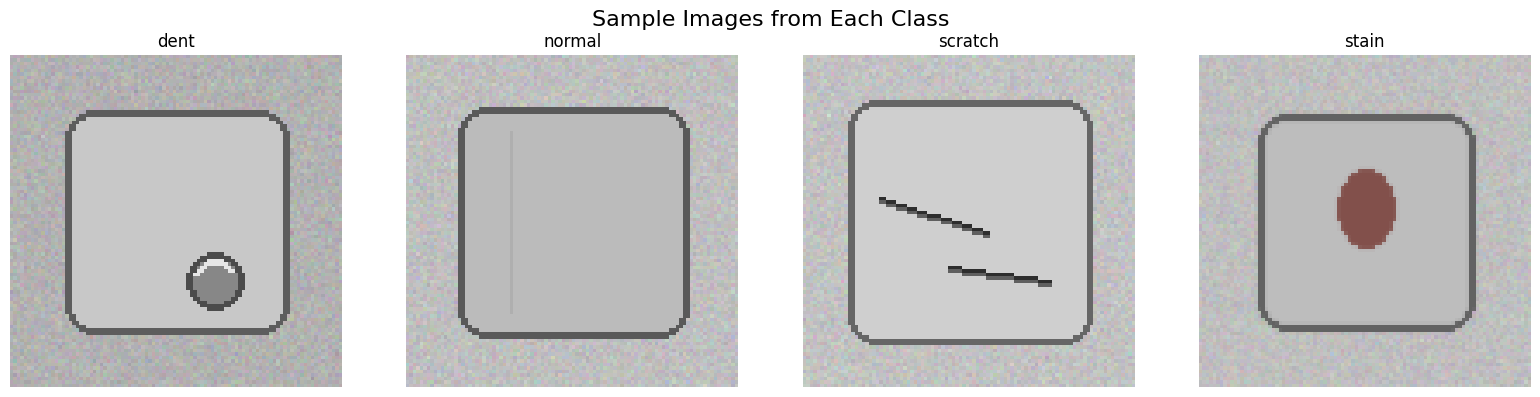

In [18]:
# ==================== TASK 2: Dataset Exploration ====================

import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

print("=== TASK 2: Dataset Exploration ===\n")

dataset_path = '/content/dataset/images'

# Get classes
classes = sorted([folder for folder in os.listdir(dataset_path)
                  if os.path.isdir(os.path.join(dataset_path, folder)) and folder != '.DS_Store'])

print("Number of classes:", len(classes))
print("Classes:", classes)

# Number of images per class
print("\nNumber of images per class:")
class_counts = {}
for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    num_images = len([f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    class_counts[cls] = num_images
    print(f" - {cls}: {num_images} images")

# Check for imbalance
print("\nDataset Balance:", "Perfectly Balanced" if len(set(class_counts.values())) == 1 else "Imbalanced")

# Image dimensions
print("\nImage Dimensions (checking samples):")
dimensions = []
sample_images = []

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if files:
        img_path = os.path.join(class_path, files[0])
        img = Image.open(img_path)
        dimensions.append(img.size)
        sample_images.append((cls, img_path))
        print(f" - {cls}: {img.size} (width x height)")

print("\nAll images have same size:", len(set(dimensions)) == 1)

# Display one sample image from each class
print("\nSample Images from each class:")
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Sample Images from Each Class', fontsize=16)

for i, (cls, img_path) in enumerate(sample_images):
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

**Observations from Dataset Exploration:**

- Total Classes: 4 (*dent*, *normal*, *scratch*, *stain*)
- Images per class: 120 each  **Perfectly balanced dataset**
- All images are of the same dimensions
- Sample images from each class have been visualized below

In [19]:
# ==================== TASK 3: Image Preprocessing ====================

import os
import shutil
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("=== TASK 3: Image Preprocessing ===\n")

dataset_path = '/content/dataset/images'
classes = sorted([folder for folder in os.listdir(dataset_path)
                  if os.path.isdir(os.path.join(dataset_path, folder)) and folder != '.DS_Store'])

# Create train and validation directories
train_dir = '/content/train'
val_dir = '/content/val'

for dir_path in [train_dir, val_dir]:
    if os.path.exists(dir_path):
        shutil.rmtree(dir_path)
    os.makedirs(dir_path)

print("Creating train-validation split and preparing for preprocessing...")

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(class_path, img), os.path.join(train_dir, cls, img))
    for img in val_imgs:
        shutil.copy(os.path.join(class_path, img), os.path.join(val_dir, cls, img))

print(" Train and Validation split completed!")
print(f"Training images   : {len(train_imgs)*len(classes)}")
print(f"Validation images : {len(val_imgs)*len(classes)}")

# Data Generators with Resizing + Normalization + Augmentation
print("\nCreating ImageDataGenerators for resizing and normalization...")

train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalization
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)   # Only normalization for validation

print("Preprocessing steps applied:")
print("- Images resized to 96x96")
print("- Pixel values normalized (0 to 1)")
print("- Data augmentation applied on training set")

=== TASK 3: Image Preprocessing ===

Creating train-validation split and preparing for preprocessing...
 Train and Validation split completed!
Training images   : 384
Validation images : 96

Creating ImageDataGenerators for resizing and normalization...
Preprocessing steps applied:
- Images resized to 96x96
- Pixel values normalized (0 to 1)
- Data augmentation applied on training set


In [20]:
# ==================== TASK 4: CNN Model Creation ====================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

print("=== TASK 4: CNN Model Creation ===\n")

# Building CNN Model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(96, 96, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

=== TASK 4: CNN Model Creation ===



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,732,292 (6.61 MB)

 Trainable params: 1,732,292 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

=== TASK 5: Model Training and Evaluation ===

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.
Training the CNN model...

Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 379ms/step - accuracy: 0.2188 - loss: 1.4880 - val_accuracy: 0.2500 - val_loss: 1.3834
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 395ms/step - accuracy: 0.2812 - loss: 1.3804 - val_accuracy: 0.5000 - val_loss: 1.3571
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 362ms/step - accuracy: 0.4167 - loss: 1.2890 - val_accuracy: 0.5625 - val_loss: 1.1716
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 362ms/step - accuracy: 0.5547 - loss: 1.0183 - val_accuracy: 0.5625 - val_loss: 0.9546
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 374ms/step - accuracy: 0.6927 - loss: 0.7676 - val_accuracy: 0.8229 - val_loss: 0.6298
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 326ms/step - accuracy: 0.7839 - loss: 0.6193 - val_accuracy: 0.8646 - val_loss: 0.3931
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 413ms/step - accuracy: 0.8802 - loss

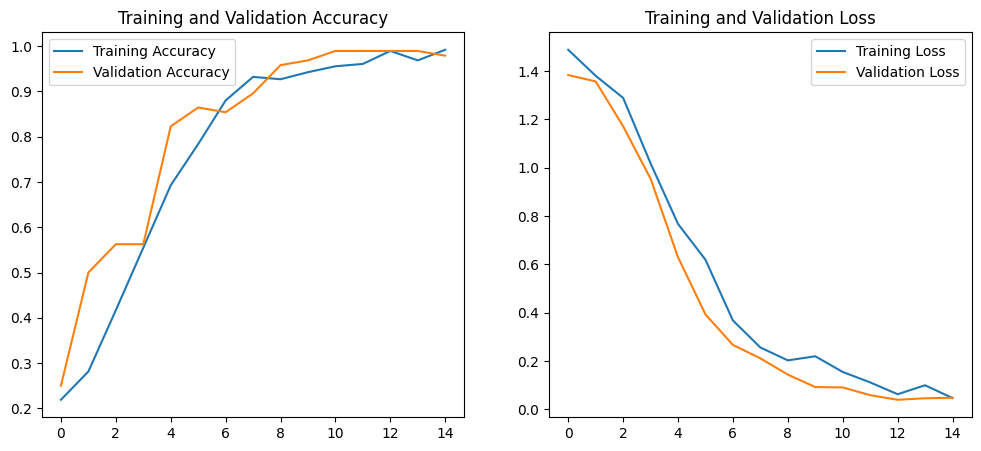

In [21]:
# ==================== TASK 5: Model Training and Evaluation ====================

from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("=== TASK 5: Model Training and Evaluation ===\n")

# Data Generators
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/train',
    target_size=(96, 96),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    '/content/val',
    target_size=(96, 96),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print("Training the CNN model...\n")

# Train the model
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    verbose=1
)

# Plot Training & Validation Accuracy/Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

=== Confusion Matrix and Detailed Evaluation ===



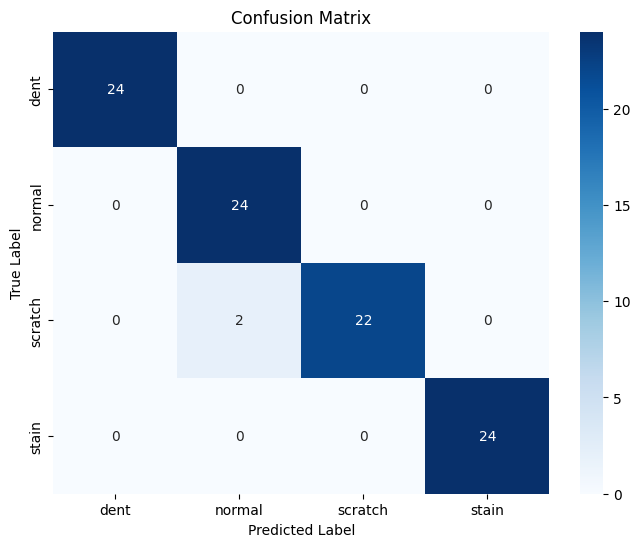

Classification Report:
              precision    recall  f1-score   support

        dent       1.00      1.00      1.00        24
      normal       0.92      1.00      0.96        24
     scratch       1.00      0.92      0.96        24
       stain       1.00      1.00      1.00        24

    accuracy                           0.98        96
   macro avg       0.98      0.98      0.98        96
weighted avg       0.98      0.98      0.98        96



In [22]:
# ==================== Confusion Matrix & Classification Report ====================

print("=== Confusion Matrix and Detailed Evaluation ===\n")

# Get predictions
val_generator.reset()
y_pred_prob = model.predict(val_generator, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = val_generator.classes

# Class names
class_names = list(val_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


Sample Predictions on Validation Images:


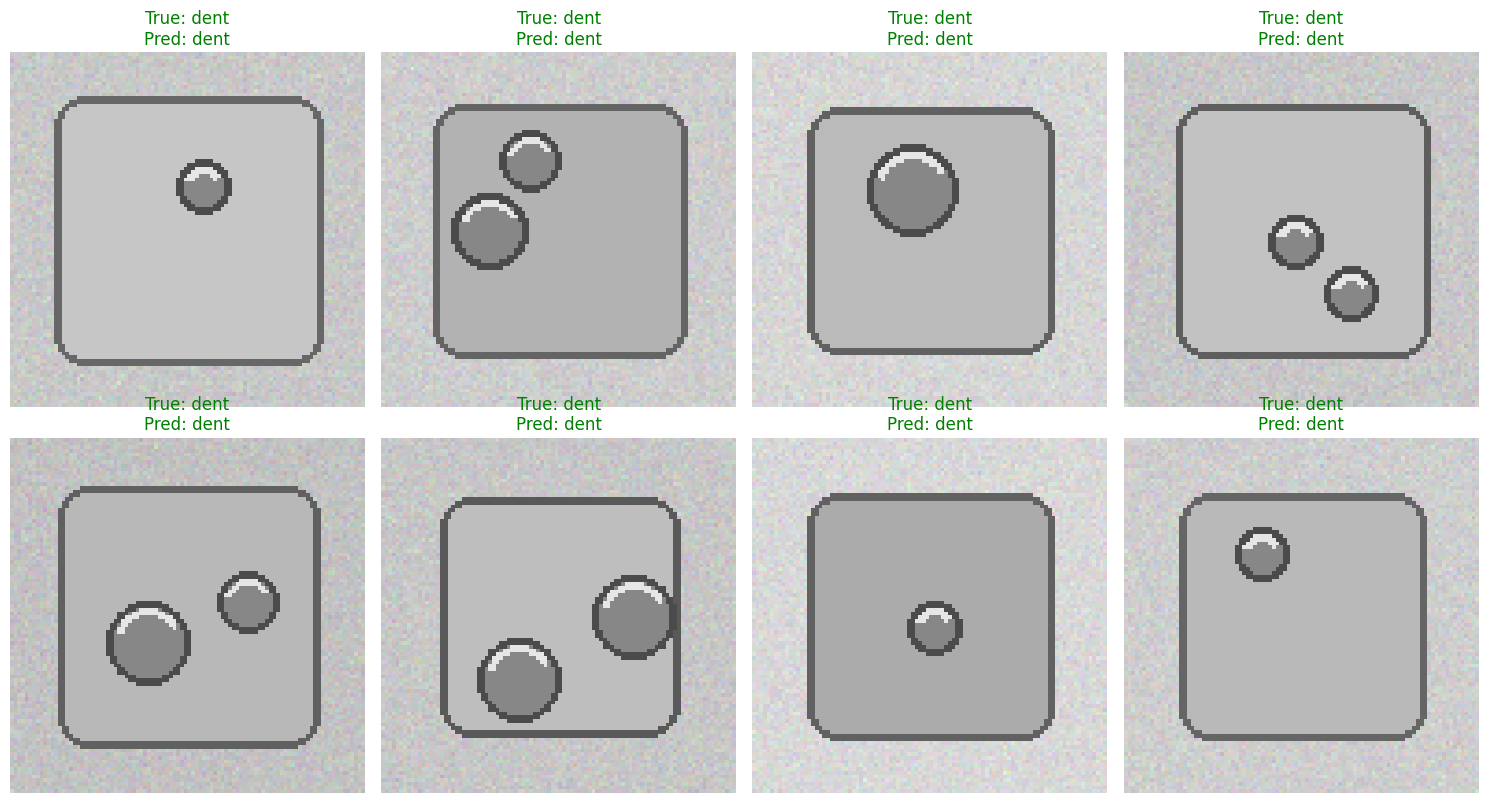

In [23]:
# ==================== Sample Predictions ====================

print("\nSample Predictions on Validation Images:")

# Get a batch of images
val_generator.reset()
images, labels = next(val_generator)
pred_prob = model.predict(images, verbose=0)
predictions = np.argmax(pred_prob, axis=1)
true_labels = np.argmax(labels, axis=1)

# Plot sample predictions
plt.figure(figsize=(15, 8))
for i in range(8):  # show 8 sample images
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i])
    true_class = class_names[true_labels[i]]
    pred_class = class_names[predictions[i]]
    color = 'green' if true_class == pred_class else 'red'
    plt.title(f"True: {true_class}\nPred: {pred_class}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()

# TASK 7: Business Use Case Mapping

**Business Use Case Mapping**

This type of CNN-based image classification model can be very useful in real-world scenarios.

I believe one of the best applications for this project is in the **Manufacturing** industry.

### Real-World Application:

In manufacturing units (especially automotive, electronics, or metal parts industry), products often get small defects like dents, scratches, or stains during production, handling, or transportation.

Manually checking every single piece is slow, tiring, and sometimes inconsistent.

With this CNN model, a company can:
- Take photos of parts on the assembly line
- Automatically detect whether the part is `normal`, has a `dent`, `scratch`, or `stain`
- Immediately reject or flag defective items

This helps in improving product quality, reducing waste, saving time, and lowering inspection costs.

It’s a practical example of how computer vision is transforming quality control in modern factories.